# Aruba population trends, 2015-2023

## Departures

Source file: Table-1.12-Departures-by-country-of-birth-and-sex.xlsx\
Source: CBS Aruba and the Population Registry Office

---
## 1. Setup

## Imports and paths

This block of code is necessary to create a reproducible notebook environment.

In [1]:
# Importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

from config.project_paths import (
    ROOT,
    DATA_RAW,
    DATA_PROCESSED,
    FIGURES
)

In [2]:
# Verify all paths to ensure stable environment

print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba
RAW DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/projects/cbs_aruba/outputs/figures


In [3]:
DEPARTURES_COUNTRY_SEX = DATA_RAW / "Table-1.12-Departures-by-country-of-birth-and-sex.xlsx"

In [4]:
# # Stop early if the source file is missing

if not DEPARTURES_COUNTRY_SEX.exists():
    raise FileNotFoundError

## 2. Load and inspect source table

In [5]:
# Read raw Excel file

raw_df = pd.read_excel(DEPARTURES_COUNTRY_SEX, skiprows=1, header=None)

In [6]:
# Drop empty row 3 in the data frame and turn all year values into Int64

df = raw_df.dropna(how="all")
df.iloc[0] = pd.to_numeric(df.iloc[0], errors="coerce").astype("Int64")

In [7]:
# Promote first row to columns and reset index

df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)

# Turn columns to a list type ad name the empyt cell at index 0 'indicator'

cols = df.columns.tolist()
#cols[0] = "indicator"
df.columns = cols

cols = pd.Series(df.columns)
df.columns = cols.ffill()

In [8]:
clean_df = df

### Building a new list of column names using a for loop

The next block of code builds a new list of column names from two header layers by combining them
- the top row (years)
- and the bottom row (Male, Female)

In [9]:
header_top = pd.Series(clean_df.columns)
header_bottom = clean_df.loc[0]

# for top, bottom in zip(header_top, header_bottom):
#     print("top   =", top)
#     print("bottom=", bottom)
#     print("---")

# Create an an empty list object where new column names will be stored
new_cols = []

# Loop that pairs values together
for top, bottom in zip(header_top, header_bottom):
    if pd.isna(top):                                  # If top header is missing, use only bottom label
        new_cols.append(str(bottom).strip())
    elif str(top) == "Indicator":
        new_cols.append("Indicator")
    else:
        new_cols.append(f"{top}_{str(bottom).strip()}")

In [10]:
header_bottom.head(5)

NaN     Country
2015       Male
2015     Female
2016       Male
2016     Female
Name: 0, dtype: object

In [11]:
# Reset index

clean_df.columns = new_cols
clean_df = clean_df.drop(index=0).reset_index(drop=True)

clean_df.columns

Index(['Country', '2015_Male', '2015_Female', '2016_Male', '2016_Female',
       '2017_Male', '2017_Female', '2018_Male', '2018_Female', '2019_Male',
       '2019_Female', '2020_Male', '2020_Female', '2021_Male', '2021_Female',
       '2022_Male', '2022_Female', '2023_Male', '2023_Female'],
      dtype='str')

In [12]:
# Remove last row containing souce information

clean_df = clean_df[
    ~clean_df["Country"].astype(str).str.startswith("Source:", na=False)
].reset_index(drop=True)

clean_df

,Country,2015_Male,2015_Female,2016_Male,2016_Female,2017_Male,2017_Female,2018_Male,2018_Female,2019_Male,2019_Female,2020_Male,2020_Female,2021_Male,2021_Female,2022_Male,2022_Female,2023_Male,2023_Female
0,Total Departures:,1376,1319,1386,1498,1662,1749,1508,1596,1579,1666,1614,1849,1298,1414,1404,1528,1366,1394
1,Aruba/ Neth. Ant.,649,607,665,667,868,829,780,764,839,801,868,933,848,850,839,840,814,743
2,The Netherlands,303,287,298,300,326,310,352,344,283,300,286,299,210,237,209,210,214,207
3,Colombia,89,120,94,171,125,166,92,155,112,166,142,253,63,101,102,177,83,167
4,Venezuela,54,57,68,43,51,49,48,42,74,85,63,51,54,44,51,72,59,53
5,Dominican Republic,37,51,45,61,43,120,32,81,47,90,57,116,26,51,45,74,41,79
6,Other,244,197,216,256,249,275,204,210,224,224,198,197,97,131,158,155,155,145


### Convert data frame to tidy format and create first plot

In [13]:
tidy_df = clean_df.melt(
    id_vars = "Country",
    var_name = "year_sex",
    value_name = "value"
)

In [14]:
tidy_df.head()

,Country,year_sex,value
0,Total Departures:,2015_Male,1376
1,Aruba/ Neth. Ant.,2015_Male,649
2,The Netherlands,2015_Male,303
3,Colombia,2015_Male,89
4,Venezuela,2015_Male,54


In [15]:
# Split the original 'year' column into two separate columns labeled 'year' and 'sex' to
# make analysis possible by having separate observations
# Then delete the 'year'column

tidy_df[["year", "sex"]] = tidy_df["year_sex"].str.split("_", expand=True)

tidy_df = tidy_df.drop(columns="year_sex")

tidy_df

,Country,value,year,sex
0,Total Departures:,1376,2015,Male
1,Aruba/ Neth. Ant.,649,2015,Male
2,The Netherlands,303,2015,Male
3,Colombia,89,2015,Male
4,Venezuela,54,2015,Male
...,...,...,...,...
121,The Netherlands,207,2023,Female
122,Colombia,167,2023,Female
123,Venezuela,53,2023,Female
124,Dominican Republic,79,2023,Female


In [16]:
# Convert year and value columns to numeric

tidy_df["year"] = pd.to_numeric(tidy_df["year"], errors="coerce").astype("Int64")
tidy_df["value"] = pd.to_numeric(tidy_df["value"], errors="coerce").astype("Int64")

tidy_df.iloc[1:,:]

,Country,value,year,sex
1,Aruba/ Neth. Ant.,649,2015,Male
2,The Netherlands,303,2015,Male
3,Colombia,89,2015,Male
4,Venezuela,54,2015,Male
5,Dominican Republic,37,2015,Male
...,...,...,...,...
121,The Netherlands,207,2023,Female
122,Colombia,167,2023,Female
123,Venezuela,53,2023,Female
124,Dominican Republic,79,2023,Female


In [17]:
# Save long (tidy) format to CSV

tidy_df.to_csv(DATA_PROCESSED / "departures_table.csv", index=False)

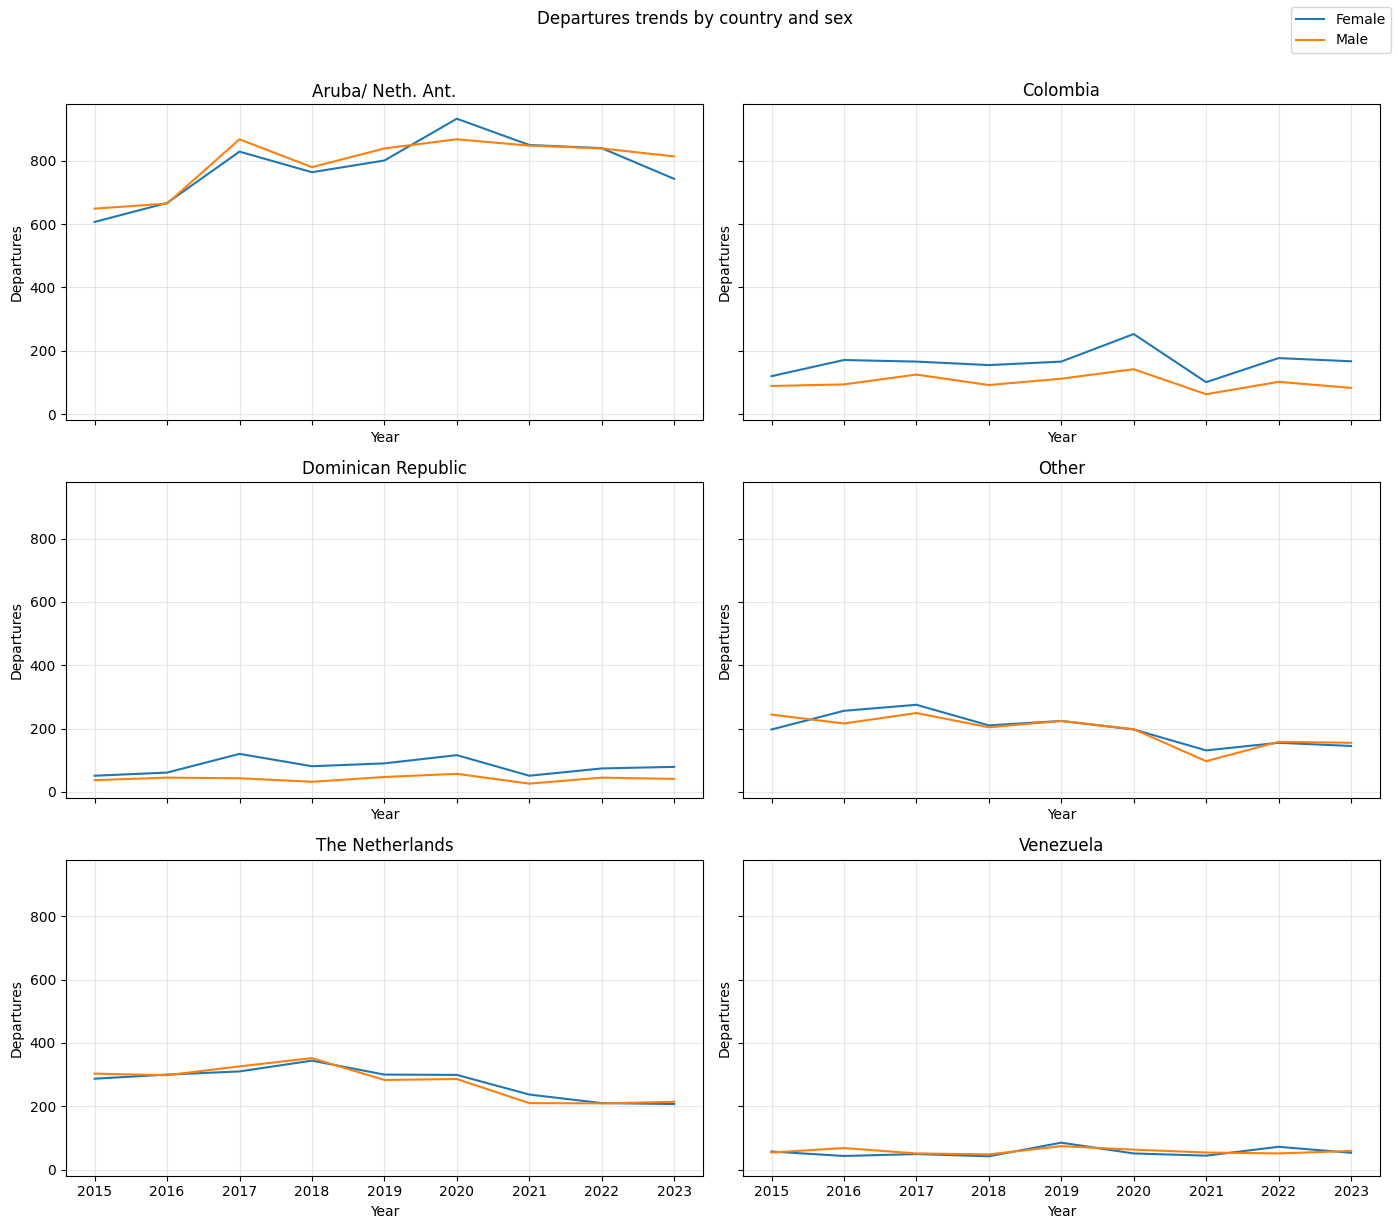

In [18]:
# Copy and clean
df_plot = tidy_df.copy()

# Keep only real country rows
df_plot = df_plot[
    ~df_plot["Country"].isin(["Total Departures:"])
].copy()

df_plot = df_plot[
    ~df_plot["Country"].astype(str).str.startswith("Source:", na=False)
].copy()

# Make sure types are correct
df_plot["year"] = pd.to_numeric(df_plot["year"], errors="coerce")
df_plot["value"] = pd.to_numeric(df_plot["value"], errors="coerce")

# Optional: rename for readability
df_plot = df_plot.rename(columns={"Country": "country"})

# Sort values
df_plot = df_plot.sort_values(["country", "sex", "year"])

countries = df_plot["country"].unique()

n = len(countries)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries):
    country_data = df_plot[df_plot["country"] == country]

    for sex, group in country_data.groupby("sex"):
        ax.plot(group["year"], group["value"], label=sex)

    ax.set_title(country)
    ax.set_xlabel("Year")
    ax.set_ylabel("Departures")
    ax.grid(True, alpha=0.3)

# Remove unused axes if any
for ax in axes[len(countries):]:
    fig.delaxes(ax)

# One legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=1)

fig.suptitle("Departures trends by country and sex", y=1.02)
plt.tight_layout()

plt.savefig(FIGURES / "depart_trends_country_sex.png", dpi=300, bbox_inches="tight")
plt.show()